| $I_s/\mathrm{mA}$ | $V_1/\mathrm{mV}$ | $V_2/\mathrm{mV}$ | $V_3/\mathrm{mV}$ | $V_4/\mathrm{mV}$ | $V_H/\mathrm{mV}$ |
|---:|---:|---:|---:|---:|---:|
| 0.50 | 40.8 | -40.8 | 40.6 | -40.7 | 40.725 |
| 1.00 | 81.1 | -81.1 | 80.8 | -80.8 | 80.950 |
| 1.50 | 120.9 | -120.8 | 120.4 | -120.4 | 120.625 |
| 2.00 | 161.4 | -161.4 | 160.8 | -160.8 | 161.100 |
| 2.50 | 201.3 | -201.3 | 200.6 | -200.6 | 200.950 |
| 3.00 | 242.0 | -241.9 | 241.0 | -241.0 | 241.475 |

数据表：
 Is/mA  V1/mV  V2/mV  V3/mV  V4/mV   VH/mV
   0.5   40.8  -40.8   40.6  -40.7  40.725
   1.0   81.1  -81.1   80.8  -80.8  80.950
   1.5  120.9 -120.8  120.4 -120.4 120.625
   2.0  161.4 -161.4  160.8 -160.8 161.100
   2.5  201.3 -201.3  200.6 -200.6 200.950
   3.0  242.0 -241.9  241.0 -241.0 241.475

线性拟合结果：
VH = 80.2414 Is + 0.5483
其中 VH 的单位为 mV，Is 的单位为 mA
R^2 = 0.999993

过原点拟合结果：
VH = 80.4945 Is
R^2 = 0.999981

尚未给出磁感应强度 B，因此只能得到 KH * B。
自由截距拟合：KH * B = 80.2414 V/A
过原点拟合：KH * B = 80.4945 V/A
若已知磁感应强度 B_T，则 KH = 斜率 / B_T。


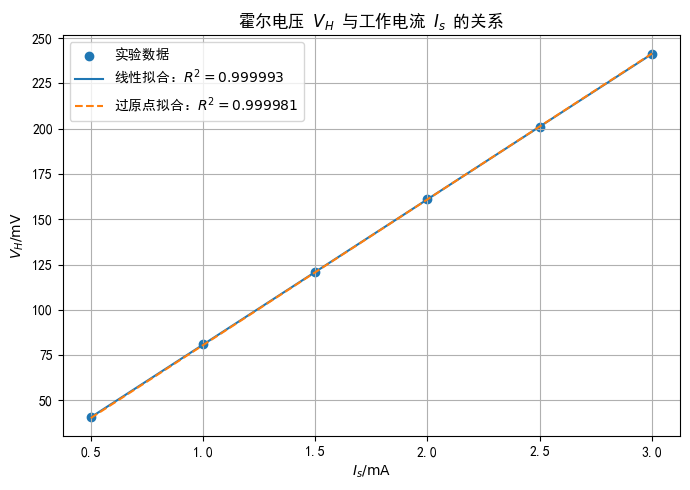

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 原始数据输入
# =========================
# Is 从 0.50 mA 到 3.00 mA，公差为 0.50 mA
Is_mA = np.arange(0.50, 3.00 + 0.50, 0.50)

# 单位：mV
# 注意：第 2、4 列应为负值，因此用 -np.abs(...) 统一修正符号
V1_mV = np.abs(np.array([40.8, 81.1, 120.9, 161.4, 201.3, 242.0]))
V2_mV = -np.abs(np.array([40.8, 81.1, 120.8, 161.4, 201.3, 241.9]))
V3_mV = np.abs(np.array([40.6, 80.8, 120.4, 160.8, 200.6, 241.0]))
V4_mV = -np.abs(np.array([40.7, 80.8, 120.4, 160.8, 200.6, 241.0]))

# =========================
# 2. 计算霍尔电压
# =========================
# 对称交换测量法：
# VH = (V1 - V2 + V3 - V4) / 4
VH_mV = (V1_mV - V2_mV + V3_mV - V4_mV) / 4

data = pd.DataFrame({
    "Is/mA": Is_mA,
    "V1/mV": V1_mV,
    "V2/mV": V2_mV,
    "V3/mV": V3_mV,
    "V4/mV": V4_mV,
    "VH/mV": VH_mV
})

print("数据表：")
print(data.to_string(index=False))

# =========================
# 3. 线性拟合：VH = a Is + b
# =========================
a, b = np.polyfit(Is_mA, VH_mV, 1)
VH_fit_mV = a * Is_mA + b

# 计算 R^2
SS_res = np.sum((VH_mV - VH_fit_mV) ** 2)
SS_tot = np.sum((VH_mV - np.mean(VH_mV)) ** 2)
R2 = 1 - SS_res / SS_tot

print()
print("线性拟合结果：")
print(f"VH = {a:.4f} Is + {b:.4f}")
print("其中 VH 的单位为 mV，Is 的单位为 mA")
print(f"R^2 = {R2:.6f}")

# =========================
# 4. 过原点拟合
# =========================
# 理论公式 VH = KH * Is * B，理想情况下应过原点
a0 = np.sum(Is_mA * VH_mV) / np.sum(Is_mA ** 2)
VH_fit0_mV = a0 * Is_mA

SS_res0 = np.sum((VH_mV - VH_fit0_mV) ** 2)
R2_0 = 1 - SS_res0 / SS_tot

print()
print("过原点拟合结果：")
print(f"VH = {a0:.4f} Is")
print(f"R^2 = {R2_0:.6f}")

# =========================
# 5. 计算霍尔灵敏度
# =========================
# 由于 1 mV / 1 mA = 1 V / A，
# 所以拟合斜率 a 的数值也可看作 V/A。
# 由 VH = KH * Is * B 可得 KH = a / B。

B_T = None
# 如果你知道 IM = 300 mA 时对应的磁感应强度 B，
# 例如 B = 0.100 T，则改成：
# B_T = 0.100

if B_T is not None:
    KH = a / B_T
    KH0 = a0 / B_T
    print()
    print("霍尔灵敏度：")
    print(f"自由截距拟合得到 KH = {KH:.4f} V/(A·T)")
    print(f"过原点拟合得到 KH = {KH0:.4f} V/(A·T)")
else:
    print()
    print("尚未给出磁感应强度 B，因此只能得到 KH * B。")
    print(f"自由截距拟合：KH * B = {a:.4f} V/A")
    print(f"过原点拟合：KH * B = {a0:.4f} V/A")
    print("若已知磁感应强度 B_T，则 KH = 斜率 / B_T。")

# =========================
# 6. 绘图验证线性关系
# =========================
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(7, 5))

plt.scatter(Is_mA, VH_mV, label="实验数据")
plt.plot(Is_mA, VH_fit_mV, label=f"线性拟合：$R^2={R2:.6f}$")
plt.plot(Is_mA, VH_fit0_mV, linestyle="--", label=f"过原点拟合：$R^2={R2_0:.6f}$")

plt.xlabel(r"$I_s/\mathrm{mA}$")
plt.ylabel(r"$V_H/\mathrm{mV}$")
plt.title(r"霍尔电压 $V_H$ 与工作电流 $I_s$ 的关系")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("hall_VH_Is_fit.png", dpi=300)
plt.show()

数据处理表：
 IM/mA  V1/mV   V2/mV  V3/mV   V4/mV  VH/mV  B1/mT  B2/mT  B3/mT  B4/mT    B/mT
  50.0  13.99  -12.99  12.99  -13.99  13.49   50.5   49.3  -49.2  -50.1  49.775
 100.0  27.48  -26.48  26.48  -27.48  26.98  100.5   99.2  -99.3 -100.0  99.750
 150.0  40.98  -39.98  39.98  -40.98  40.48  150.5  149.1 -149.0 -149.7 149.575
 200.0  54.47  -53.47  53.47  -54.47  53.97  200.5  198.7 -198.6 -199.4 199.300
 250.0  67.96  -66.96  66.96  -67.96  67.46  248.9  248.2 -248.1 -248.8 248.500
 300.0  81.45  -80.45  80.45  -81.45  80.95  297.3  297.6 -297.5 -298.2 297.650
 350.0  94.94  -93.94  93.94  -94.94  94.44  347.5  346.8 -346.7 -347.4 347.100
 400.0 108.43 -107.43 107.43 -108.43 107.93  396.5  395.8 -395.7 -396.4 396.100
 450.0 121.93 -120.93 120.93 -121.93 121.43  445.3  444.6 -444.5 -445.2 444.900
 500.0 135.42 -134.42 134.42 -135.42 134.92  493.8  493.1 -493.0 -493.7 493.400

线性拟合结果：
VH-IM: VH = 0.269839 IM -0.000667, R^2 = 1.000000
B-IM:  B  = 0.985921 IM +1.476667, R^2 = 0.999983
VH-B

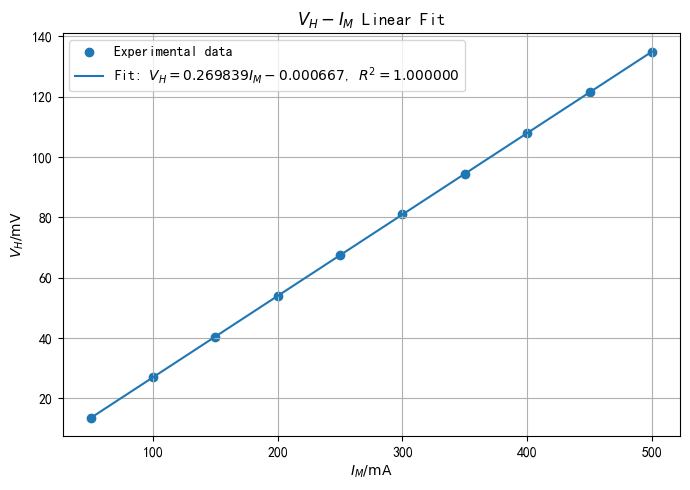

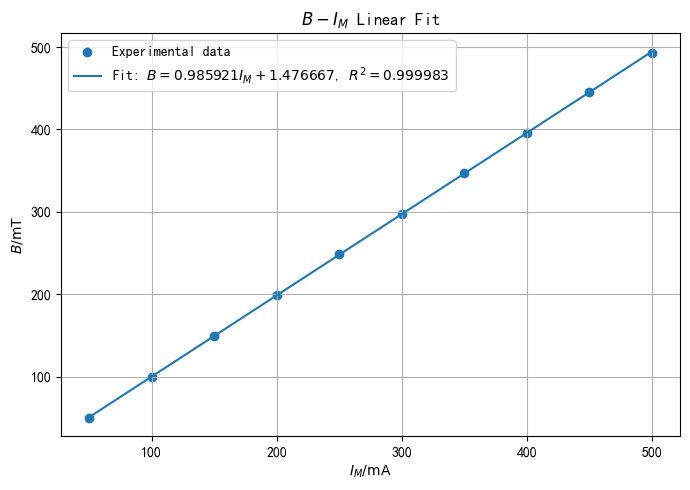

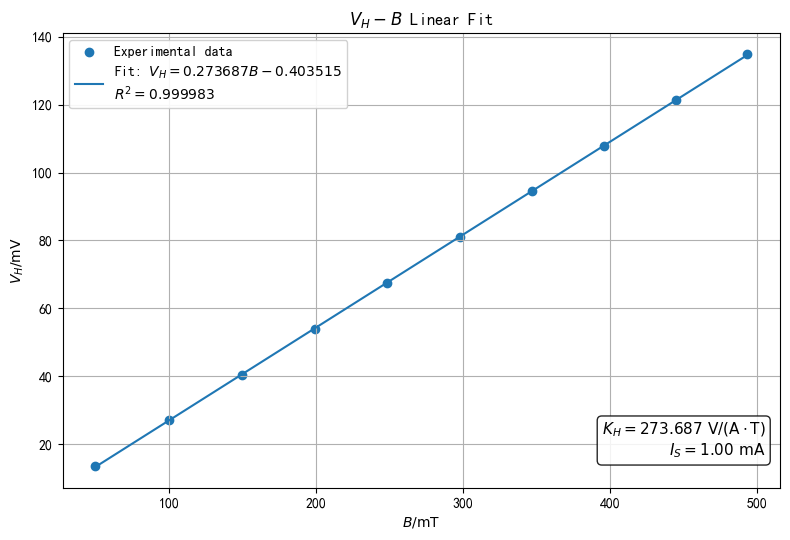

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 数据录入
# =========================

# 励磁电流 IM，单位：mA
IM_mA = np.arange(50, 501, 50, dtype=float)

# 霍尔电压四次测量值，单位：mV
V1_mV = np.array([13.99, 27.48, 40.98, 54.47, 67.96, 81.45, 94.94, 108.43, 121.93, 135.42])
V2_mV = -np.array([12.99, 26.48, 39.98, 53.47, 66.96, 80.45, 93.94, 107.43, 120.93, 134.42])
V3_mV = np.array([12.99, 26.48, 39.98, 53.47, 66.96, 80.45, 93.94, 107.43, 120.93, 134.42])
V4_mV = -np.array([13.99, 27.48, 40.98, 54.47, 67.96, 81.45, 94.94, 108.43, 121.93, 135.42])

# 磁感应强度四次测量值，单位：mT
B1_mT = np.array([50.5, 100.5, 150.5, 200.5, 248.9, 297.3, 347.5, 396.5, 445.3, 493.8])
B2_mT = np.array([49.3, 99.2, 149.1, 198.7, 248.2, 297.6, 346.8, 395.8, 444.6, 493.1])
B3_mT = -np.array([49.2, 99.3, 149.0, 198.6, 248.1, 297.5, 346.7, 395.7, 444.5, 493.0])
B4_mT = -np.array([50.1, 100.0, 149.7, 199.4, 248.8, 298.2, 347.4, 396.4, 445.2, 493.7])

# 固定工作电流 IS，单位：A
# 如果实验中 IS 不是 1.00 mA，只需要修改这里
IS_A = 1.00e-3

# =========================
# 2. 对称交换法计算 VH 和 B
# =========================

VH_mV = (V1_mV - V2_mV + V3_mV - V4_mV) / 4
B_mT = (B1_mT + B2_mT - B3_mT - B4_mT) / 4

data = pd.DataFrame({
    "IM/mA": IM_mA,
    "V1/mV": V1_mV,
    "V2/mV": V2_mV,
    "V3/mV": V3_mV,
    "V4/mV": V4_mV,
    "VH/mV": VH_mV,
    "B1/mT": B1_mT,
    "B2/mT": B2_mT,
    "B3/mT": B3_mT,
    "B4/mT": B4_mT,
    "B/mT": B_mT,
})

data.to_csv("hall_processed_data.csv", index=False, encoding="utf-8-sig")

print("数据处理表：")
print(data.to_string(index=False))

# =========================
# 3. 线性拟合函数
# =========================

def linear_fit(x, y):
    k, b = np.polyfit(x, y, 1)
    y_fit = k * x + b
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return k, b, y_fit, r2

# VH-IM 拟合
k_VH_IM, b_VH_IM, VH_fit_IM, R2_VH_IM = linear_fit(IM_mA, VH_mV)

# B-IM 拟合
k_B_IM, b_B_IM, B_fit_IM, R2_B_IM = linear_fit(IM_mA, B_mT)

# VH-B 拟合
k_VH_B, b_VH_B, VH_fit_B, R2_VH_B = linear_fit(B_mT, VH_mV)

# 注意：k_VH_B 的单位为 mV/mT，数值上等于 V/T
# 由 VH = KH * IS * B 得 KH = k_VH_B / IS
KH = k_VH_B / IS_A

print()
print("线性拟合结果：")
print(f"VH-IM: VH = {k_VH_IM:.6f} IM {b_VH_IM:+.6f}, R^2 = {R2_VH_IM:.6f}")
print(f"B-IM:  B  = {k_B_IM:.6f} IM {b_B_IM:+.6f}, R^2 = {R2_B_IM:.6f}")
print(f"VH-B:  VH = {k_VH_B:.6f} B {b_VH_B:+.6f}, R^2 = {R2_VH_B:.6f}")
print(f"霍尔灵敏度 KH = {KH:.3f} V/(A·T)")

# =========================
# 4. 绘图并导出图片
# =========================

plt.rcParams["axes.unicode_minus"] = False

# 图 1：VH-IM
plt.figure(figsize=(7, 5))
plt.scatter(IM_mA, VH_mV, label="Experimental data")
plt.plot(
    IM_mA,
    VH_fit_IM,
    label=fr"Fit: $V_H={k_VH_IM:.6f}I_M{b_VH_IM:+.6f}$, $R^2={R2_VH_IM:.6f}$"
)
plt.xlabel(r"$I_M/\mathrm{mA}$")
plt.ylabel(r"$V_H/\mathrm{mV}$")
plt.title(r"$V_H-I_M$ Linear Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("hall_VH_vs_IM.png", dpi=300)
plt.show()

# 图 2：B-IM
plt.figure(figsize=(7, 5))
plt.scatter(IM_mA, B_mT, label="Experimental data")
plt.plot(
    IM_mA,
    B_fit_IM,
    label=fr"Fit: $B={k_B_IM:.6f}I_M{b_B_IM:+.6f}$, $R^2={R2_B_IM:.6f}$"
)
plt.xlabel(r"$I_M/\mathrm{mA}$")
plt.ylabel(r"$B/\mathrm{mT}$")
plt.title(r"$B-I_M$ Linear Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("hall_B_vs_IM.png", dpi=300)
plt.show()

# 图 3：VH-B，并在图中给出霍尔灵敏度 KH
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(B_mT, VH_mV, label="Experimental data")
ax.plot(
    B_mT,
    VH_fit_B,
    label=fr"Fit: $V_H={k_VH_B:.6f}B{b_VH_B:+.6f}$" "\n"
          fr"$R^2={R2_VH_B:.6f}$"
)

# 将图例放在左上角
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)

# 将霍尔灵敏度放在右下角，避免与图例重叠
KH_text = (
    fr"$K_H={KH:.3f}\ \mathrm{{V/(A\cdot T)}}$" "\n"
    fr"$I_S={IS_A * 1000:.2f}\ \mathrm{{mA}}$"
)

ax.text(
    0.98,
    0.06,
    KH_text,
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

ax.set_xlabel(r"$B/\mathrm{mT}$")
ax.set_ylabel(r"$V_H/\mathrm{mV}$")
ax.set_title(r"$V_H-B$ Linear Fit")
ax.grid(True)

fig.tight_layout()
fig.savefig("hall_VH_vs_B.png", dpi=300, bbox_inches="tight")
plt.show()